In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# For SMOTE
from imblearn.over_sampling import SMOTENC

# For saving models
import joblib

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("All imports successful.")

All imports successful.


In [4]:
# Load the raw CSV
df = pd.read_csv('../data/destinations_raw.csv')

print(f"Initial shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst 2 rows:")
df.head(10)

Initial shape: (155, 35)
Columns: 35

First 2 rows:


,destination_id,destination_city,country,region,avg_annual_temp_c,seasonal_range_c,dry_season_months,cost_per_day_avg_usd,meal_budget_usd,hotel_night_avg_usd,flight_cost_usd,museum_count,monument_count,festival_score,beach_score,scenic_score,wellness_score,culture_score,hiking_score,nightlife_score,family_score,luxury_score,safety_score,tourist_density_score,adventure_sports_score,near_mountains,near_beach,best_season,visa_requirement,english_friendly_score,public_transport_score,latitude,longitude,source_label_hint,travel_style
0,DST-0001,Kathmandu,Nepal,South Asia,20.0,15.0,"Oct,Nov,Dec,Jan,Feb,Mar",35,4,25,800,8,12,7,1,8,3,6,9,4,3,1,7,5,9,1,0,Oct-Nov,Visa on Arrival,6,4,27.7172,85.3240,Himalayas trekking culture temples,Adventure
1,DST-0002,Queenstown,New Zealand,Oceania,12.0,18.0,"Dec,Jan,Feb,Mar",120,15,95,1100,5,3,5,3,9,4,4,8,6,7,6,9,7,10,1,0,Dec-Feb,eTA required,10,5,-45.0312,168.6626,Adventure sports bungee skiing,Adventure
2,DST-0003,Interlaken,Switzerland,Western Europe,9.0,22.0,"Jun,Jul,Aug,Sep",150,20,120,600,4,2,4,2,10,5,5,9,3,6,7,9,6,10,1,0,Jun-Sep,Schengen Visa,8,8,46.6863,7.8632,Alps paragliding lakes hiking,Adventure
3,DST-0004,Torres del Paine,Chile,South America,8.0,14.0,"Nov,Dec,Jan,Feb,Mar",90,12,70,950,1,1,2,1,10,2,2,10,1,2,1,9,4,9,1,0,Nov-Mar,Visa-Free,5,3,-51.0000,-73.0000,Patagonia trekking glaciers wilderness,Adventure
4,DST-0005,Banff,Canada,North America,2.0,28.0,"Jun,Jul,Aug,Sep",130,18,100,400,3,2,4,1,10,3,3,9,3,5,5,9,6,8,1,0,Jun-Sep,eTA required,10,4,51.1784,-115.5708,Rockies hiking skiing lakes,Adventure
5,DST-0006,Chamonix,France,Western Europe,7.0,24.0,"Jun,Jul,Aug,Sep",140,20,110,350,3,3,3,1,10,4,4,10,2,4,6,9,5,10,1,0,Jun-Sep,Schengen Visa,7,6,45.9237,6.8697,Mont Blanc climbing skiing alpine,Adventure
6,DST-0007,Huacachina,Peru,South America,24.0,8.0,"May,Jun,Jul,Aug,Sep,Oct",50,7,35,700,2,3,3,2,7,2,3,3,3,2,1,7,5,5,0,0,May-Oct,Visa-Free,4,3,-14.0875,-75.7633,Desert oasis sandboarding dune buggy,Adventure
7,DST-0008,Moab,United States,North America,15.0,30.0,"Mar,Apr,May,Sep,Oct",110,15,90,300,2,1,3,1,9,2,2,8,2,4,2,8,5,8,1,0,Mar-May,ESTA or Visa,10,2,38.5733,-109.5498,Arches mountain biking climbing desert,Adventure
8,DST-0009,El Chaltén,Argentina,South America,7.0,16.0,"Nov,Dec,Jan,Feb,Mar",65,8,45,900,1,1,1,1,10,1,2,10,1,1,1,9,3,9,1,0,Nov-Mar,Visa-Free,4,2,-49.3315,-72.8865,Fitz Roy trekking Patagonia hiking,Adventure
9,DST-0010,Pokhara,Nepal,South Asia,20.0,14.0,"Oct,Nov,Dec,Jan,Feb,Mar",30,4,20,750,3,5,5,1,9,3,4,8,3,2,1,7,4,8,1,0,Oct-Nov,Visa on Arrival,6,3,28.2096,83.9856,Annapurna trekking paragliding lakes,Adventure


In [5]:
# Check duplicates by ID before removal
print(f"Duplicates by destination_id before: {df.duplicated(subset='destination_id').sum()}")

# Remove duplicates keeping first occurrence
df = df.drop_duplicates(subset='destination_id', keep='first')

print(f"Shape after ID dedup: {df.shape}")
print(f"Rows removed: {155 - len(df)}")

Duplicates by destination_id before: 0
Shape after ID dedup: (155, 35)
Rows removed: 0


In [6]:
# Check duplicates by city+country before removal
duplicates_before = df.duplicated(subset=['destination_city', 'country'], keep=False).sum()
print(f"Duplicate rows by city+country before: {duplicates_before}")

# Remove duplicates keeping first occurrence
df = df.drop_duplicates(subset=['destination_city', 'country'], keep='first')

print(f"\nShape after city+country dedup: {df.shape}")
print(f"Rows removed: {duplicates_before}")

# Show the duplicates that were removed
print(f"\nExpected: Should remove 6 rows (1 from each of 6 duplicate pairs)")

Duplicate rows by city+country before: 12

Shape after city+country dedup: (149, 35)
Rows removed: 12

Expected: Should remove 6 rows (1 from each of 6 duplicate pairs)


In [7]:
# Verify no duplicates remain
print(f"Remaining duplicates by destination_id: {df.duplicated(subset='destination_id').sum()}")
print(f"Remaining duplicates by city+country: {df.duplicated(subset=['destination_city', 'country']).sum()}")

print(f"\nFinal shape after deduplication: {df.shape}")

Remaining duplicates by destination_id: 0
Remaining duplicates by city+country: 0

Final shape after deduplication: (149, 35)


In [8]:
# Check missing values before fix
print("Missing values before fix:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Find the row with missing seasonal_range_c
print("\nRow with missing seasonal_range_c:")
print(df[df['seasonal_range_c'].isnull()][['destination_id', 'destination_city', 'country', 'seasonal_range_c']])

# Fix: impute with median of the column
median_value = df['seasonal_range_c'].median()
df.loc[df['seasonal_range_c'].isnull(), 'seasonal_range_c'] = median_value

print(f"\nImputed with median value: {median_value}")

# Verify fix
print(f"\nMissing values after fix: {df.isnull().sum().sum()}")

Missing values before fix:
seasonal_range_c    1
dtype: int64

Row with missing seasonal_range_c:
    destination_id destination_city country  seasonal_range_c
138       DST-0139          Entebbe  Uganda               NaN

Imputed with median value: 14.0

Missing values after fix: 0


In [9]:
# Identify string columns
string_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"String columns to clean ({len(string_cols)}):")
print(string_cols)

# Strip whitespace
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

print("\nWhitespace stripped from all string columns.")

# Verify a sample
print("\nSample after stripping:")
print(df[string_cols[:3]].head(2))

String columns to clean (9):
['destination_id', 'destination_city', 'country', 'region', 'dry_season_months', 'best_season', 'visa_requirement', 'source_label_hint', 'travel_style']

Whitespace stripped from all string columns.

Sample after stripping:
  destination_id destination_city      country
0       DST-0001        Kathmandu        Nepal
1       DST-0002       Queenstown  New Zealand


C:\Users\Jawad\AppData\Local\Temp\ipykernel_15320\266202710.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object']).columns.tolist()


In [10]:
print("=== FINAL CLEANING VERIFICATION ===\n")

print(f"Final shape: {df.shape}")
print(f"Expected: 149 rows × 35 columns\n")

print(f"Missing values total: {df.isnull().sum().sum()}")
print(f"Expected: 0\n")

print(f"Duplicate rows by ID: {df.duplicated(subset='destination_id').sum()}")
print(f"Duplicate rows by city+country: {df.duplicated(subset=['destination_city', 'country']).sum()}")
print(f"Expected: 0 for both\n")

print("Class distribution after cleaning:")
print(df['travel_style'].value_counts())

print("\n✅ Cleaning complete. Ready for SMOTE and preprocessing.")

=== FINAL CLEANING VERIFICATION ===

Final shape: (149, 35)
Expected: 149 rows × 35 columns

Missing values total: 0
Expected: 0

Duplicate rows by ID: 0
Duplicate rows by city+country: 0
Expected: 0 for both

Class distribution after cleaning:
travel_style
Culture       47
Adventure     38
Budget        25
Relaxation    17
Family        14
Luxury         8
Name: count, dtype: int64

✅ Cleaning complete. Ready for SMOTE and preprocessing.


In [11]:
# Separate features and target
X = df.drop(columns=['travel_style'])
y = df['travel_style']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget distribution before SMOTE:")
print(y.value_counts())

X shape: (149, 34)
y shape: (149,)

Target distribution before SMOTE:
travel_style
Culture       47
Adventure     38
Budget        25
Relaxation    17
Family        14
Luxury         8
Name: count, dtype: int64


In [12]:
# SMOTENC needs to know which columns are categorical
# Identify categorical columns (object type)

# Auto-detect object columns
object_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns detected: {len(object_cols)}")
print(object_cols)

# For SMOTENC, we need indices of categorical columns
categorical_indices = [X.columns.get_loc(col) for col in object_cols if col in X.columns]
print(f"\nCategorical indices for SMOTENC: {categorical_indices}")

Categorical columns detected: 8
['destination_id', 'destination_city', 'country', 'region', 'dry_season_months', 'best_season', 'visa_requirement', 'source_label_hint']

Categorical indices for SMOTENC: [0, 1, 2, 3, 6, 27, 28, 33]


C:\Users\Jawad\AppData\Local\Temp\ipykernel_15320\3836294674.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = X.select_dtypes(include=['object']).columns.tolist()


In [13]:
from imblearn.over_sampling import SMOTENC

# Apply SMOTENC
smote = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42,
    k_neighbors=3
)

X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Original X shape: {X.shape}")
print(f"Resampled X shape: {X_resampled.shape}")
print(f"\nTarget distribution after SMOTE:")
print(y_resampled.value_counts())

Original X shape: (149, 34)
Resampled X shape: (282, 34)

Target distribution after SMOTE:
travel_style
Adventure     47
Culture       47
Luxury        47
Relaxation    47
Family        47
Budget        47
Name: count, dtype: int64


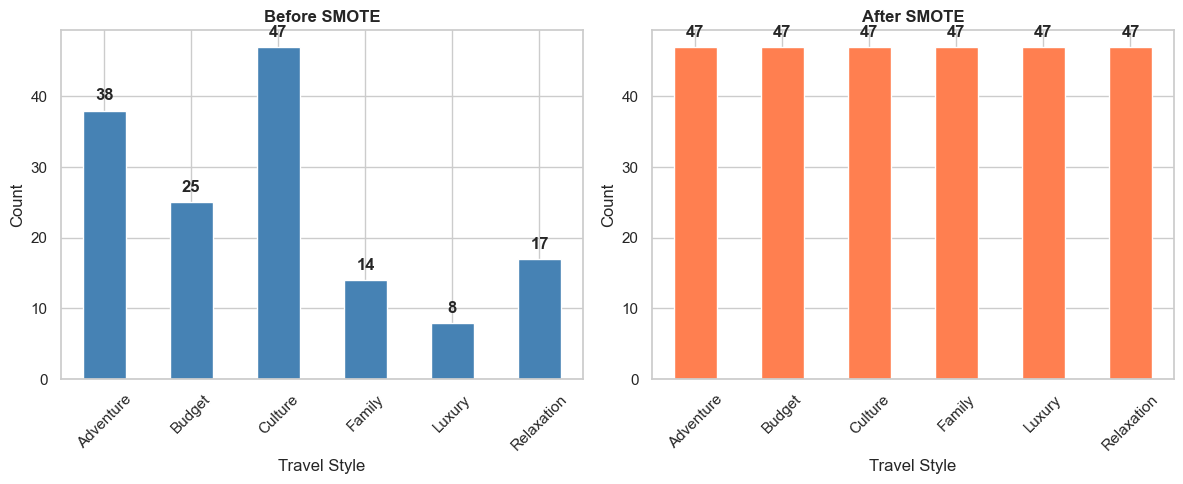

Before SMOTE counts:
travel_style
Adventure     38
Budget        25
Culture       47
Family        14
Luxury         8
Relaxation    17
Name: count, dtype: int64

After SMOTE counts:
travel_style
Adventure     47
Budget        47
Culture       47
Family        47
Luxury        47
Relaxation    47
Name: count, dtype: int64

✅ All classes now balanced at 47 samples each.


In [15]:
# Bar plot of before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE (original y)
y_before = y.value_counts().sort_index()
y_before.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Travel Style')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(y_before.values):
    axes[0].text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

# After SMOTE (y_resampled)
y_after = y_resampled.value_counts().sort_index()
y_after.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Travel Style')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(y_after.values):
    axes[1].text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Before SMOTE counts:")
print(y_before)
print("\nAfter SMOTE counts:")
print(y_after)
print(f"\n✅ All classes now balanced at {y_after.min()} samples each.")

In [16]:
from sklearn.model_selection import train_test_split

# Split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_resampled, y_resampled, test_size=0.40, stratify=y_resampled, random_state=42
)

# Split temp into 50% val, 50% test (20% each of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nVal class distribution:\n{y_val.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

Train shape: (169, 34)
Val shape:   (56, 34)
Test shape:  (57, 34)

Train class distribution:
travel_style
Adventure     29
Budget        28
Culture       28
Family        28
Luxury        28
Relaxation    28
Name: count, dtype: int64

Val class distribution:
travel_style
Adventure      9
Budget         9
Culture       10
Family         9
Luxury         9
Relaxation    10
Name: count, dtype: int64

Test class distribution:
travel_style
Adventure      9
Budget        10
Culture        9
Family        10
Luxury        10
Relaxation     9
Name: count, dtype: int64


In [17]:
# Identify column types for preprocessing
# We dropped travel_style already, now identify numeric vs categorical

# Numeric columns (int64 and float64, excluding identifiers we'll drop)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns (object type)
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols[:10], "...")
print(f"\nCategorical columns ({len(categorical_cols)}):")
print(categorical_cols)

# Columns to drop (identifiers that shouldn't be used in ML)
cols_to_drop = ['destination_id', 'destination_city', 'country', 'source_label_hint']
print(f"\nColumns to drop (identifiers): {cols_to_drop}")

Numeric columns (26):
['avg_annual_temp_c', 'seasonal_range_c', 'cost_per_day_avg_usd', 'meal_budget_usd', 'hotel_night_avg_usd', 'flight_cost_usd', 'museum_count', 'monument_count', 'festival_score', 'beach_score'] ...

Categorical columns (8):
['destination_id', 'destination_city', 'country', 'region', 'dry_season_months', 'best_season', 'visa_requirement', 'source_label_hint']

Columns to drop (identifiers): ['destination_id', 'destination_city', 'country', 'source_label_hint']


C:\Users\Jawad\AppData\Local\Temp\ipykernel_15320\3613960547.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Remove identifier columns from training data
X_train_clean = X_train.drop(columns=cols_to_drop)
X_val_clean = X_val.drop(columns=cols_to_drop)
X_test_clean = X_test.drop(columns=cols_to_drop)

# Update numeric and categorical lists after dropping columns
numeric_cols_clean = [c for c in numeric_cols if c not in cols_to_drop]
categorical_cols_clean = [c for c in categorical_cols if c not in cols_to_drop]

print(f"Numeric columns (after dropping): {len(numeric_cols_clean)}")
print(f"Categorical columns (after dropping): {len(categorical_cols_clean)}")
print(f"\nCategorical columns to encode: {categorical_cols_clean}")

# Numeric pipeline: impute median, then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute with most frequent, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols_clean),
    ('cat', categorical_pipeline, categorical_cols_clean)
])

# Fit on training data only
preprocessor.fit(X_train_clean)

print("\nPreprocessor fitted successfully!")
print(f"Output features: {preprocessor.transform(X_train_clean[:1]).shape[1]}")

Numeric columns (after dropping): 26
Categorical columns (after dropping): 4

Categorical columns to encode: ['region', 'dry_season_months', 'best_season', 'visa_requirement']

Preprocessor fitted successfully!
Output features: 100


In [20]:
import joblib

# Save the preprocessor
joblib.dump(preprocessor, '../models/preprocessor.joblib')
print("Saved: backend/ml/models/preprocessor.joblib")

# Transform all splits
X_train_processed = preprocessor.transform(X_train_clean)
X_val_processed = preprocessor.transform(X_val_clean)
X_test_processed = preprocessor.transform(X_test_clean)

# Save processed arrays as .npy files
np.save('../models/X_train_processed.npy', X_train_processed)
np.save('../models/X_val_processed.npy', X_val_processed)
np.save('../models/X_test_processed.npy', X_test_processed)
np.save('../models/y_train.npy', y_train.values)
np.save('../models/y_val.npy', y_val.values)
np.save('../models/y_test.npy', y_test.values)

print(f"\nX_train_processed shape: {X_train_processed.shape}")
print(f"X_val_processed shape: {X_val_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"\nAll arrays saved successfully!")

Saved: backend/ml/models/preprocessor.joblib

X_train_processed shape: (169, 100)
X_val_processed shape: (56, 100)
X_test_processed shape: (57, 100)

All arrays saved successfully!
